## Data Preperation

In [198]:
import numpy as np
import pandas as pd

In [199]:
df = pd.read_csv('cars.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [200]:
df.shape

(11914, 16)

In [201]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [202]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [203]:
str_cols = list(df.dtypes[df.dtypes == 'str'].index)
str_cols

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [204]:
for col in str_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [205]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [206]:
# Alternative and faster, cleaner way
df[str_cols].apply(lambda x: x.str.lower().str.replace(' ', '_'))

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,bmw,1_series_m,premium_unleaded_(required),manual,rear_wheel_drive,"factory_tuner,luxury,high-performance",compact,coupe
1,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,convertible
2,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,high-performance",compact,coupe
3,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,coupe
4,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,luxury,compact,convertible
...,...,...,...,...,...,...,...,...
11909,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11910,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11911,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11912,acura,zdx,premium_unleaded_(recommended),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback


In [207]:
for col in df.columns:
    print(col, df[col].unique()[:5])
    print(df[col].nunique())
    print()

make <StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model <StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year [2011 2012 2013 1992 1993]
28

engine_fuel_type <StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp [335. 300. 230. 320. 172.]
356

engine_cylinders [ 6.  4.  5.  8. 12.]
9

transmission_type <StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels <StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors [ 2.  4.  3. nan]
3

market_category <StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Exploratory Data Analysis (EDA)

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

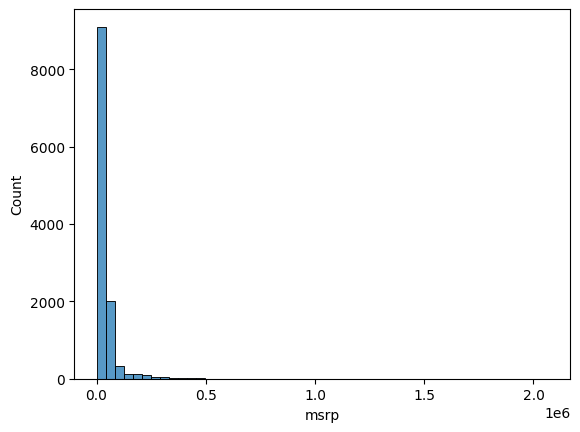

In [209]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

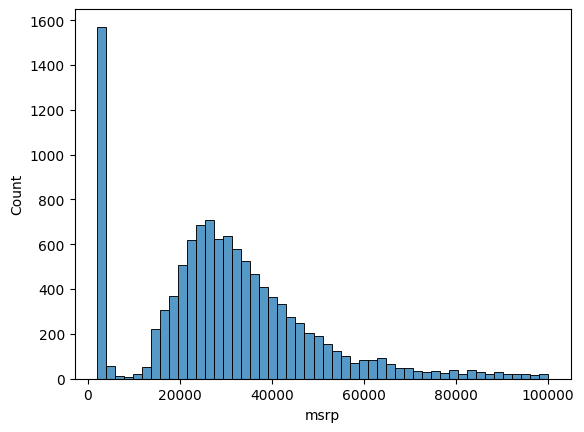

In [210]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [211]:
np.log1p([1,10,100,1000,10000,100000,1000000])

array([ 0.69314718,  2.39789527,  4.61512052,  6.90875478,  9.21044037,
       11.51293546, 13.81551156])

In [212]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

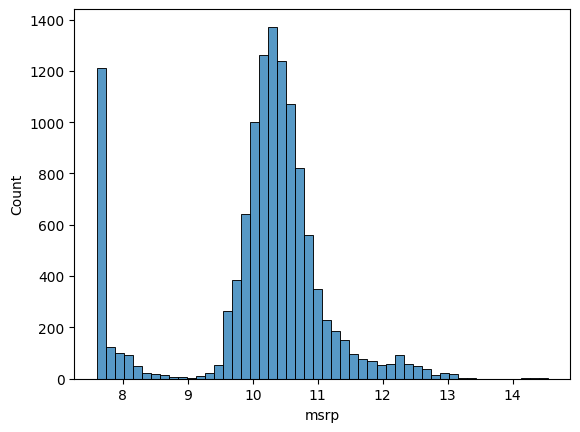

In [213]:
sns.histplot(price_logs, bins=50)

## The Validation Framework

In [214]:
n_rows = len(df)
train_idx = int(n_rows * 0.6)
val_idx = int(n_rows * 0.2)
test_idx = n_rows - (train_idx + val_idx)
print(train_idx, val_idx, test_idx)

7148 2382 2384


In [215]:
idx = np.arange(n_rows)
np.random.seed(2)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [216]:
train_df = df.iloc[idx[:train_idx]]
val_df = df.iloc[idx[train_idx:train_idx + val_idx]]
test_df = df.iloc[idx[train_idx + val_idx:]]

In [217]:
print(train_df.shape, val_df.shape, test_df.shape)

(7148, 16) (2382, 16) (2384, 16)


In [218]:
train_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [219]:
val_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300
2420,volkswagen,cc,2017,premium_unleaded_(recommended),200.0,4.0,automated_manual,front_wheel_drive,4.0,performance,midsize,sedan,31,22,873,37820
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775


In [220]:
test_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6337,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,17595
9814,kia,sorento,2015,regular_unleaded,290.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,25,18,1720,26700
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120


In [221]:
y_train = np.log1p(train_df.msrp.values)
y_val = np.log1p(val_df.msrp.values)
y_test = np.log1p(test_df.msrp.values)

In [222]:
del train_df['msrp']
del val_df['msrp']
del test_df['msrp']

## Linear Regression

In [223]:
train_df.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 7557, dtype: object

In [224]:
xi = train_df.iloc[10][['engine_hp', 'city_mpg', 'popularity']].values
xi

array([np.float64(453.0), np.int64(11), np.int64(86)], dtype=object)

In [225]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [226]:
def linear_regression(xi, w):
    n = len(xi)
    
    res = 0.0
    for i in range(n):
        res += (xi[i] * w[i])
    pred = w0 + res
    return pred

In [227]:
np.expm1(linear_regression(xi, w))

np.float64(222347.22211010658)

In [228]:
def dot(xi, w):
    n = len(xi)

    res = 0.0
    for i in range(n):
        res += (xi[i] * w[i])
    
    return res

In [229]:
def linear_regression(xi, w0, w):
    return w0 + dot(xi, w)

In [230]:
np.expm1(linear_regression(xi, w0, w))

np.float64(222347.22211010658)

In [231]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [232]:
def linear_regression(xi, w):
    xi_new = np.ones(1)
    xi_new = np.append(xi_new, xi)
    return dot(xi_new, w)

print(np.expm1(linear_regression(xi, w_new)))

222347.2221101062


In [233]:
X = train_df.iloc[10:14][['engine_hp', 'city_mpg', 'popularity']].values
X

array([[ 453.,   11.,   86.],
       [ 182.,   20., 1385.],
       [ 162.,   20.,  436.],
       [ 553.,   16., 2774.]])

In [234]:
def linear_regression(X, w):
    X = np.column_stack((np.ones(X.shape[0]), X))
    return np.dot(X, w)

print(np.expm1(linear_regression(X, w_new)))

[2.22347222e+05 2.84929338e+05 3.49604044e+04 1.59571075e+08]


## Training Linear Regression: Normal Equation

In [235]:
X = train_df.iloc[10:20][['engine_hp', 'city_mpg', 'popularity']].values
X

array([[ 453.,   11.,   86.],
       [ 182.,   20., 1385.],
       [ 162.,   20.,  436.],
       [ 553.,   16., 2774.],
       [ 272.,   18., 3105.],
       [ 160.,   29.,  640.],
       [ 348.,   17., 1439.],
       [ 151.,   18.,  436.],
       [ 210.,   15., 1851.],
       [ 164.,   18., 5657.]])

### Normal Equation
w = ((XT * X)^-1) * XT * y

In [236]:
XTX = np.dot(X.T, X)
XTX

array([[8.8487100e+05, 4.4983000e+04, 4.7257080e+06],
       [4.4983000e+04, 3.5040000e+03, 3.1810200e+05],
       [4.7257080e+06, 3.1810200e+05, 5.7550085e+07]])

In [237]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.41273885e-06, -3.68738459e-05, -7.64197506e-08],
       [-3.68738459e-05,  9.71241237e-04, -2.34054826e-06],
       [-7.64197506e-08, -2.34054826e-06,  3.65884865e-08]])

In [238]:
np.dot(XTX_inv, XTX).round()

array([[ 1., -0., -0.],
       [ 0.,  1.,  0.],
       [-0., -0.,  1.]])

In [239]:
y= y_train[10:20]
y

array([13.08107461, 10.42439221, 10.23995979, 12.20092944, 10.88183247,
       10.28520627, 10.42676533,  7.60140233, 10.13642301,  7.60140233])

In [240]:
w = XTX_inv.dot(X.T).dot(y)
w

array([ 1.74021263e-02,  3.19456454e-01, -1.65625255e-04])

In [241]:
def linear_regression(X, w):
    #X = np.column_stack((np.ones(X.shape[0]), X))
    return np.dot(X, w)

predictions = linear_regression(X, w)

In [242]:
print(predictions)
print(y)

[11.38294044  9.32692509  9.13606093 14.27523465  9.96932811 11.94257722
 11.24836493  8.30572463  8.13972099  7.66722282]
[13.08107461 10.42439221 10.23995979 12.20092944 10.88183247 10.28520627
 10.42676533  7.60140233 10.13642301  7.60140233]


In [243]:
print(y - predictions)

[ 1.69813417  1.09746712  1.10389886 -2.07430521  0.91250436 -1.65737095
 -0.8215996  -0.7043223   1.99670202 -0.06582048]


In [244]:
def train_linear_regression(X, y):
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w
w = train_linear_regression(X, y)

In [245]:
def predict_linear_regression(X, w):
    return np.dot(X, w)

In [246]:
predictions = predict_linear_regression(X, w)
predictions

array([11.38294044,  9.32692509,  9.13606093, 14.27523465,  9.96932811,
       11.94257722, 11.24836493,  8.30572463,  8.13972099,  7.66722282])

## Car Price Baseline Model

In [247]:
train_df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [248]:
train_df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [249]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
X = train_df[base]
X.head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
2735,148.0,4.0,33,24,1385
6720,132.0,4.0,32,25,2031
5878,148.0,4.0,37,28,640
11190,90.0,4.0,18,16,873
4554,385.0,8.0,21,15,5657


In [250]:
X.isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [251]:
X = X.fillna(X.median(numeric_only=True))
X.isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [252]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.91328684,
       10.28247178, 10.45380308], shape=(7148,))

In [253]:
print(len(y_train))
print(X.shape)

7148
(7148, 5)


In [254]:
X = X.values #convert to numpy array

In [255]:
w = train_linear_regression(X, y_train)

In [256]:
predictions = predict_linear_regression(X, w)
print(predictions.shape)

(7148,)


<Axes: ylabel='Count'>

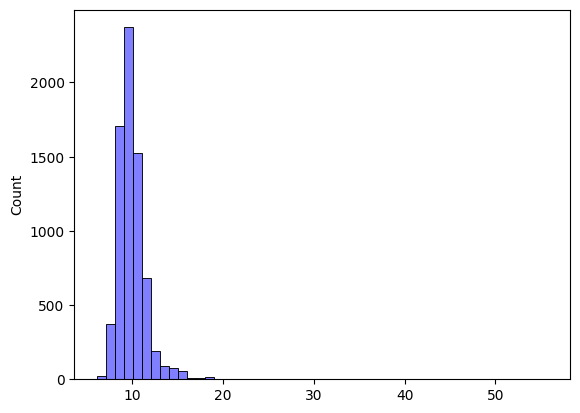

In [257]:
sns.histplot(predictions, bins=50, color='blue', alpha=0.5)

<Axes: ylabel='Count'>

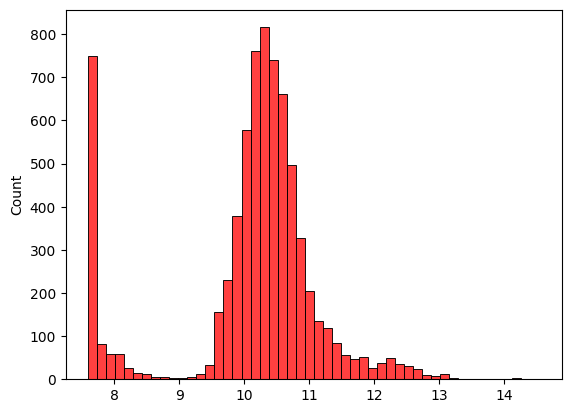

In [258]:
sns.histplot(y_train, bins=50, color='red')

## Root Mean Squared Error (RMSE)

In [259]:
predictions

array([ 9.10106333,  8.93966714,  9.6775648 , ..., 11.34977199,
        8.99566787,  9.61182597], shape=(7148,))

In [260]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.91328684,
       10.28247178, 10.45380308], shape=(7148,))

In [261]:
def rmse(y_pred, y):
    se = (y - y_pred) ** 2
    mse = np.mean(se)
    return np.sqrt(mse)

In [262]:
print(rmse(predictions, y_train))

1.4014915274404918


## Validating the model

In [263]:
def prepare_X(df):
    df = df.copy()
    selected_columns = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
    X = df[selected_columns]
    X = X.fillna(X.median(numeric_only=True))
    return X.values

In [264]:
X_train = prepare_X(train_df)
X_val = prepare_X(val_df)

In [265]:
w = train_linear_regression(X_train, y_train)

In [266]:
y_pred = predict_linear_regression(X_val, w)

In [267]:
print(rmse(y_pred, y_val))

1.2972309833061992


## Simple Feature Engineering

In [268]:
train_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [269]:
train_df.year.max()

np.int64(2017)

In [270]:
def prepare_X(df):
    df = df.copy()
    selected_columns = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
    df['age'] = 2017 - df['year']
    features = selected_columns + ['age']
    X = df[features]
    X = X.fillna(X.mode().iloc[0])
    return X.values

In [271]:
X_train = prepare_X(train_df)
X_train[:10]

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       [9.000e+01, 4.000e+00, 1.800e+01, 1.600e+01, 8.730e+02, 2.600e+01],
       [3.850e+02, 8.000e+00, 2.100e+01, 1.500e+01, 5.657e+03, 0.000e+00],
       [1.700e+02, 5.000e+00, 2.900e+01, 2.200e+01, 8.730e+02, 9.000e+00],
       [5.000e+02, 8.000e+00, 2.400e+01, 1.400e+01, 5.200e+02, 4.000e+00],
       [3.150e+02, 6.000e+00, 3.200e+01, 2.100e+01, 3.916e+03, 2.000e+00],
       [5.430e+02, 1.200e+01, 1.600e+01, 1.000e+01, 6.700e+01, 5.000e+00],
       [2.020e+02, 6.000e+00, 1.800e+01, 1.300e+01, 5.657e+03, 1.300e+01]])

In [272]:
X_val = prepare_X(val_df)
w = train_linear_regression(X_train, y_train)
y_pred = predict_linear_regression(X_val, w)
print(rmse(y_pred, y_val)) # rmse is slighly lower, because selecting age variable has an impact on the model

1.2821754952854656


## Categorical Variables

In [273]:
train_df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [274]:
cat_cols = list(df.dtypes[df.dtypes == 'str'].index)
cat_cols

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [275]:
(train_df['number_of_doors'] == 4).astype(int)

2735     0
6720     1
5878     1
11190    0
4554     1
        ..
11913    1
3602     1
434      0
1902     0
9334     1
Name: number_of_doors, Length: 7148, dtype: int64

In [276]:
 def prepare_X(df):
      df = df.copy()
      numeric_columns = list(df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index)
      categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

      df['age'] = 2017 - df['year']
      numeric_columns.append('age')

      df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

      new_cols = {}
      for cat_col in categorical_columns:
          for value in df[cat_col].unique():
              new_cols["{}_{}".format(cat_col, value)] = (df[cat_col] == value).astype(int)

      df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

      features = numeric_columns + list(new_cols.keys())
      return df[features].values

In [277]:
X_train = prepare_X(train_df)
X_val = prepare_X(val_df)
w = train_linear_regression(X_train, y_train)
y_pred = predict_linear_regression(X_val, w)
print(rmse(y_pred, y_val)) #rmse is even lower

0.5070644087265885


## Regularization

$$ \text{Cost} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \lambda \sum_{j=1}^{m}{w_j^2} $$

$$ \text{Cost} = \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2_2 + \lambda \|\mathbf{w}\|^2_2 $$

$$ \mathbf{w} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y} $$

In [278]:
def train_linear_regression_reg(X, y, r=0.001):
    XTX = np.dot(X.T, X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w

In [279]:
X_val = prepare_X(val_df)
w = train_linear_regression_reg(X_train, y_train, 0.01)
y_pred = predict_linear_regression(X_val, w)
print(rmse(y_pred, y_val))

0.5070644119935803


## Tuning the model

In [280]:
for r in [0, 0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 2, 3, 4, 5]:
    X_val = prepare_X(val_df)
    w = train_linear_regression_reg(X_train, y_train, 0.01)
    y_pred = predict_linear_regression(X_val, w)
    score = rmse(y_pred, y_val)
    print(r, score)

0 0.5070644119935803
1e-07 0.5070644119935803
1e-06 0.5070644119935803
1e-05 0.5070644119935803
0.0001 0.5070644119935803
0.001 0.5070644119935803
0.01 0.5070644119935803
0.1 0.5070644119935803
1 0.5070644119935803
2 0.5070644119935803
3 0.5070644119935803
4 0.5070644119935803
5 0.5070644119935803


## Using the model

In [281]:
df_train_full = pd.concat([train_df, val_df])
y_train_full = np.concatenate([y_train, y_val])
X_train_full = prepare_X(df_train_full)
X_test = prepare_X(test_df)
w = train_linear_regression_reg(X_train_full, y_train_full, 0.001)
y_pred = predict_linear_regression(X_test, w)
score = rmse(y_pred, y_test)
print(score)

0.5078116437415668


In [289]:
data = test_df.iloc[30].to_dict()
data #in real project data for api comes as a dict

{'make': 'audi',
 'model': 'tt_rs',
 'year': 2012,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 360.0,
 'engine_cylinders': 5.0,
 'transmission_type': 'manual',
 'driven_wheels': 'all_wheel_drive',
 'number_of_doors': 2.0,
 'market_category': 'factory_tuner,luxury,high-performance',
 'vehicle_size': 'compact',
 'vehicle_style': 'coupe',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 3105}

In [290]:
data = pd.DataFrame([data])
data #the model trained with pandas dataframes, that is why the data transformed to df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,audi,tt_rs,2012,premium_unleaded_(required),360.0,5.0,manual,all_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,25,18,3105


In [291]:
data_prepared = prepare_X(data)

In [292]:
y_pred = predict_linear_regression(data_prepared, w)
predicted_price = np.expm1(y_pred)
real_price = np.expm1(y_test[30])

In [293]:
print(predicted_price, real_price)

[39837.74440914] 56849.999999999956
